# Assignment 1: Data Preprocessing and EDA for E‑Commerce Orders

This notebook is your working template for **Assignment 1**.

You will:
- Load **four tables** (`orders`, `order_items`, `order_shipping`, `payments`).
- Join them into a single order-level dataset.
- Clean and transform the data.
- Perform basic EDA and visualization.

Work **top-to-bottom**. Complete each sub-part in the order they appear before proceeding.

## Submitted by

Group number on Canvas:  
Student ID (AxxxxxxxZ) | NUSNet ID (exxxxxxx) | Name (as it appears on Canvas)
-----------------------|----------------------|-------------------------------
Member 1 ID | Member 1 NUSNet | Member 1 Name
Member 2 ID | Member 2 NUSNet | Member 2 Name
Member 3 ID | Member 3 NUSNet | Member 3 Name
Member 4 ID | Member 4 NUSNet | Member 4 Name

## Setup

Run the cell below to import the required Python packages.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn
import seaborn as sns

plt.style.use('seaborn-v0_8')

---
## Part 1: Data Preprocessing (10 marks)

### 1.1 Data Loading & Joining (4 marks)

We first load each table, inspect it, and then join them into a single DataFrame.


#### Load the CSV files

**Task:**
- Dowload the four CSV files from canvas and upload them under the 'files' tab for this colab instance
- Load the four CSV files using `pd.read_csv()` into:
  - `df_orders`
  - `df_order_items`
  - `df_shipping`
  - `df_payments`

Update the filenames/paths if necessary.

In [ ]:
# ANSWER: load the CSV files
df_orders = pd.read_csv('orders.csv')
df_order_items = pd.read_csv('order_items.csv')
df_shipping = pd.read_csv('order_shipping.csv')
df_payments = pd.read_csv('payments.csv')

print('All files loaded successfully.')

All files loaded successfully.


#### Inspect each table

**Task:**
- For **each** DataFrame, display:
  - `head()` (first 5 rows)
  - `shape` (rows, columns)

This helps you understand the raw structure before joining.

In [ ]:
# ANSWER: inspect the DataFrames
dfs = {
    "Orders": df_orders,
    "Order Items": df_order_items,
    "Shipping": df_shipping,
    "Payments": df_payments
}

for name, df in dfs.items():
    print(f"--- {name} ---")
    print(f"Shape: {df.shape}")
    display(df.head())
    print("\n")

--- Orders ---
Shape: (100000, 6)


,order_id,order_status,order_purchase_hour,order_purchase_dayofweek,order_purchase_month,order_total_value
0,sdv-id-whzjUX,shipped,10,4,4,744.312535
1,sdv-id-gqShVM,delivered,19,2,4,1030.521912
2,sdv-id-vtaqcY,delivered,18,4,8,28.472994
3,sdv-id-xkqwdo,invoiced,23,1,8,143.914263
4,sdv-id-sGyHvQ,delivered,19,0,2,16.944537




--- Order Items ---
Shape: (100000, 8)


,order_id,num_items,num_unique_products,num_unique_sellers,total_item_price,avg_item_price,total_freight_value,top_product_category
0,sdv-id-whzjUX,1,1,1,352.420029,369.966521,68.790159,construction_tools_construction
1,sdv-id-gqShVM,1,1,1,1580.187928,1089.284136,84.603289,auto
2,sdv-id-vtaqcY,1,1,1,45.969263,36.969754,24.022637,furniture_decor
3,sdv-id-xkqwdo,1,1,1,146.023435,126.755360,16.945349,consoles_games
4,sdv-id-sGyHvQ,1,1,1,30.525812,22.797409,17.785846,air_conditioning




--- Shipping ---
Shape: (100000, 2)


,order_id,customer_state
0,sdv-id-whzjUX,Massachusetts
1,sdv-id-gqShVM,Ohio
2,sdv-id-vtaqcY,Wisconsin
3,sdv-id-xkqwdo,Michigan
4,sdv-id-sGyHvQ,Nevada




--- Payments ---
Shape: (100000, 2)


,order_id,payment_type
0,sdv-id-whzjUX,voucher
1,sdv-id-gqShVM,voucher
2,sdv-id-vtaqcY,voucher
3,sdv-id-xkqwdo,credit_card
4,sdv-id-sGyHvQ,credit_card


#### Join the tables on `order_id` to create a single order-level DataFrame

**Task:**
- Perform **inner joins** on `order_id` so that only orders present in **all** tables remain.
- Join order tables in this order:
  1. `df_orders` with `df_order_items`
  2. result with `df_shipping`
  3. result with `df_payments`
- Store the final DataFrame as `df_orders_full`.
- Display `head()` and `shape` for `df_orders_full`.


In [ ]:
# ANSWER: join the tables
df_merge_1 = pd.merge(df_orders, df_order_items, on='order_id', how='inner')
df_merge_2 = pd.merge(df_merge_1, df_shipping, on='order_id', how='inner')
df_orders_full = pd.merge(df_merge_2, df_payments, on='order_id', how='inner')

print(f"Final Shape of df_orders_full: {df_orders_full.shape}")
display(df_orders_full.head())

Final Shape of df_orders_full: (100000, 15)


,order_id,order_status,order_purchase_hour,order_purchase_dayofweek,order_purchase_month,order_total_value,num_items,num_unique_products,num_unique_sellers,total_item_price,avg_item_price,total_freight_value,top_product_category,customer_state,payment_type
0,sdv-id-whzjUX,shipped,10,4,4,744.312535,1,1,1,352.420029,369.966521,68.790159,construction_tools_construction,Massachusetts,voucher
1,sdv-id-gqShVM,delivered,19,2,4,1030.521912,1,1,1,1580.187928,1089.284136,84.603289,auto,Ohio,voucher
2,sdv-id-vtaqcY,delivered,18,4,8,28.472994,1,1,1,45.969263,36.969754,24.022637,furniture_decor,Wisconsin,voucher
3,sdv-id-xkqwdo,invoiced,23,1,8,143.914263,1,1,1,146.023435,126.755360,16.945349,consoles_games,Michigan,credit_card
4,sdv-id-sGyHvQ,delivered,19,0,2,16.944537,1,1,1,30.525812,22.797409,17.785846,air_conditioning,Nevada,credit_card


---
### 1.2 Data Cleaning (3 marks)

We now clean `df_orders_full` so it is ready for analysis.

#### Handle missing values

**Task:**
- For **numerical** columns: replace missing values with the **median** of that column.
- For **categorical** columns: replace missing values with the **mode** (most frequent value).
- Drop any rows where `order_id` or `payment_type` is missing (if any remain)

Work directly on `df_orders_full`.

In [ ]:
from numpy._core import numeric
# ANSWER: Handle missing values

# Separate numeric and categorical columns
numeric_cols = df_orders_full.select_dtypes(include=np.number).columns
categorical_cols = df_orders_full.select_dtypes(exclude=np.number).columns

# Fill numeric columns with Median
for col in numeric_cols:
  median_val = df_orders_full[col].median()
  df_orders_full[col] = df_orders_full[col].fillna(median_val)

# Fill categorical columns with Mode
for col in categorical_cols:
  if not df_orders_full[col].mode().empty:
    mode_val = df_orders_full[col].mode()[0]
    df_orders_full[col] = df_orders_full[col].fillna(mode_val)

# Drop rows where specific critical columns are still missing
df_orders_full.dropna(subset=['order_id', 'payment_type'], inplace=True)

print("Missing values handled.")

Missing values handled.


#### Remove clearly invalid numeric records

**Task:**
- Remove rows where:
  - `num_items` ≤ 0, or
  - `order_total_value` ≤ 0, or
  - `total_item_price` < 0, or
  - `total_freight_value` < 0.


In [ ]:
# ANSWER: filter invalid numeric records
condition = (
    (df_orders_full['num_items'] > 0) &
    (df_orders_full['order_total_value'] > 0) &
    (df_orders_full['total_item_price'] >= 0) &
    (df_orders_full['total_freight_value'] >= 0)
)

# Apply the filter
df_orders_full = df_orders_full[condition]

print("Invalid records removed.")
print(f"Shape after filtering invalid records: {df_orders_full.shape}")

Invalid records removed.
Shape after filtering invalid records: (89175, 15)


#### Check cleanliness and key uniqueness

**Task:**
- Confirm there are **no null values** in `df_orders_full`.
- Check that `order_id` is unique (one row per order).


In [ ]:
# ANSWER: final cleaning checks

# Confirm no null values
total_nulls = df_orders_full.isnull().sum().sum()
print(f"Total null values remaining: {total_nulls}")

# Check that order_id is unique
is_unique = df_orders_full['order_id'].is_unique
print(f"Is order_id unique? {is_unique}")

Total null values remaining: 0
Is order_id unique? True


---
### 1.3 Data Transformation (3 marks)

Next, we perform sanity checks and create new features that will be useful later.

#### Sanity checks on counts and values

**Task:**
- Keep only rows where both:
  - `num_items` ≥ `num_unique_products`,
  - `order_total_value` ≥ `total_item_price + total_freight_value`


In [ ]:
# ANSWER: apply sanity checks
# condition 1: Total items count must be >= count of unique products
cond_items = df_orders_full['num_items'] >= df_orders_full['num_unique_products']

# condition 2: Total order value must be >= total item price + total freight value
cond_value = df_orders_full['order_total_value'] >= (df_orders_full['total_item_price'] + df_orders_full['total_freight_value'])

# Apply both conditions，keep rows that satisfy both conditions
df_orders_full = df_orders_full[cond_items & cond_value]

print(f"Shape after sanity checks: {df_orders_full.shape}")

Shape after sanity checks: (46287, 15)


#### Create `order_value_per_item`

**Task:**
- Create a new column `order_value_per_item` defined as `total_item_price / num_items`.


In [ ]:
# ANSWER: create order_value_per_item
# Calculate value per item
df_orders_full['order_value_per_item'] = df_orders_full['total_item_price'] / df_orders_full['num_items']

# Display the first few rows to verify
display(df_orders_full[['total_item_price', 'num_items', 'order_value_per_item']].head())

,total_item_price,num_items,order_value_per_item
0,352.420029,1,352.420029
5,289.242639,1,289.242639
8,26.893468,1,26.893468
12,37.790896,1,37.790896
14,169.528323,3,56.509441


#### Create `order_size_category`

**Task:**
- Create a new categorical column `order_size_category` with values:
  - "Small" if `num_items` ≤ 2
  - "Medium" if `num_items` ≤ 5
  - "Large" if `num_items` > 5


In [ ]:
# ANSWER: create order_size_category
def order_size_category(num_items):
  if num_items <= 2:
    return 'Small'
  elif num_items <= 5:
    return 'Medium'
  else:
    return 'Large'

df_orders_full['order_size_category'] = df_orders_full['num_items'].apply(order_size_category)

# Verify the distribution of categories
print(df_orders_full['order_size_category'].value_counts())

order_size_category
Small     40026
Medium     4543
Large      1718
Name: count, dtype: int64


#### Final transformation check

**Task:**
- Confirm there are no null values in `df_orders_full`.
- Display:
  - `head()`
  - `shape`
  - `info()`


In [ ]:
# ANSWER: final transformation summary
# 1. Confirm no null values
print(f"Any nulls left? {df_orders_full.isnull().values.any()}")

# 2. Display summary
display(df_orders_full.head())
print(f"\nFinal Shape: {df_orders_full.shape}")
print("\n")
df_orders_full.info()

Any nulls left? False


,order_id,order_status,order_purchase_hour,order_purchase_dayofweek,order_purchase_month,order_total_value,num_items,num_unique_products,num_unique_sellers,total_item_price,avg_item_price,total_freight_value,top_product_category,customer_state,payment_type,order_value_per_item,order_size_category
0,sdv-id-whzjUX,shipped,10,4,4,744.312535,1,1,1,352.420029,369.966521,68.790159,construction_tools_construction,Massachusetts,voucher,352.420029,Small
5,sdv-id-dbopoJ,delivered,19,2,3,1556.667902,1,1,1,289.242639,1354.621410,15.394619,health_beauty,Vermont,credit_card,289.242639,Small
8,sdv-id-FSEOvM,delivered,15,4,8,62.060506,1,1,1,26.893468,48.485654,18.751282,luggage_accessories,South Carolina,debit_card,26.893468,Small
12,sdv-id-bQcBUR,delivered,21,0,8,73.873470,1,1,1,37.790896,75.704909,8.670875,computers_accessories,Kentucky,credit_card,37.790896,Small
14,sdv-id-MPxIXB,delivered,13,5,5,361.961537,3,3,3,169.528323,50.132979,34.731146,pet_shop,Missouri,voucher,56.509441,Medium



Final Shape: (46287, 17)


<class 'pandas.core.frame.DataFrame'>
Index: 46287 entries, 0 to 99997
Data columns (total 17 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   order_id                  46287 non-null  object 
 1   order_status              46287 non-null  object 
 2   order_purchase_hour       46287 non-null  int64  
 3   order_purchase_dayofweek  46287 non-null  int64  
 4   order_purchase_month      46287 non-null  int64  
 5   order_total_value         46287 non-null  float64
 6   num_items                 46287 non-null  int64  
 7   num_unique_products       46287 non-null  int64  
 8   num_unique_sellers        46287 non-null  int64  
 9   total_item_price          46287 non-null  float64
 10  avg_item_price            46287 non-null  float64
 11  total_freight_value       46287 non-null  float64
 12  top_product_category      46287 non-null  object 
 13  customer_state            46287 non-nu

### 1.4 Data Storage

We now save the cleaned, joined, and transformed dataset.

#### 1.4A Save cleaned dataset

**Task:**
- Save `df_orders_full` as `ecommerce_orders_cleaned.csv` (without the index).

In [ ]:
# ANSWER: save to CSV
# Save the dataframe to a CSV file, excluding the index
df_orders_full.to_csv('ecommerce_orders_cleaned.csv', index=False)

print("File 'ecommerce_orders_cleaned.csv' saved successfully.")

File 'ecommerce_orders_cleaned.csv' saved successfully.


---
## Part 2: EDA & Data Visualization (4 marks)

We now reload the cleaned dataset and explore it.

### 2.0 Load Transformed Dataset

#### 2.0 Reload CSV

**Task:**
- Load `ecommerce_orders_cleaned.csv` into `df_orders_cleaned`.
- Display `head()` and `shape`.

In [ ]:
# ANSWER: load cleaned dataset
df_orders_cleaned = pd.read_csv('ecommerce_orders_cleaned.csv')

print(f"Shape of df_orders_cleaned: {df_orders_cleaned.shape}")
display(df_orders_cleaned.head())

Shape of df_orders_cleaned: (46287, 17)


,order_id,order_status,order_purchase_hour,order_purchase_dayofweek,order_purchase_month,order_total_value,num_items,num_unique_products,num_unique_sellers,total_item_price,avg_item_price,total_freight_value,top_product_category,customer_state,payment_type,order_value_per_item,order_size_category
0,sdv-id-whzjUX,shipped,10,4,4,744.312535,1,1,1,352.420029,369.966521,68.790159,construction_tools_construction,Massachusetts,voucher,352.420029,Small
1,sdv-id-dbopoJ,delivered,19,2,3,1556.667902,1,1,1,289.242639,1354.621410,15.394619,health_beauty,Vermont,credit_card,289.242639,Small
2,sdv-id-FSEOvM,delivered,15,4,8,62.060506,1,1,1,26.893468,48.485654,18.751282,luggage_accessories,South Carolina,debit_card,26.893468,Small
3,sdv-id-bQcBUR,delivered,21,0,8,73.873470,1,1,1,37.790896,75.704909,8.670875,computers_accessories,Kentucky,credit_card,37.790896,Small
4,sdv-id-MPxIXB,delivered,13,5,5,361.961537,3,3,3,169.528323,50.132979,34.731146,pet_shop,Missouri,voucher,56.509441,Medium


### 2.1 Unique Categories and Payment Types (1 mark)

**Task:**
- Compute the number of unique values in `top_product_category` and `payment_type`.
- Display:
  - The top 5 product categories by order count.
  - The top 3 payment types by order count.

In [ ]:
# ANSWER: unique counts and top values
# Compute number of unique values
unique_cat = df_orders_cleaned['top_product_category'].nunique()
unique_payment = df_orders_cleaned['payment_type'].nunique()

print(f"Number of unique product categories: {unique_cat}")
print(f"Number of unique payment types: {unique_payment}")

print('\n')
print("Top 5 Product Categories:")
print(df_orders_cleaned['top_product_category'].value_counts().head(5))

print('\n')
print("Top 3 Payment Types:")
print(df_orders_cleaned['payment_type'].value_counts().head(3))

Number of unique product categories: 71
Number of unique payment types: 5


Top 5 Product Categories:
top_product_category
bed_bath_table           6419
health_beauty            4208
furniture_decor          3413
computers_accessories    3386
telephony                2570
Name: count, dtype: int64


Top 3 Payment Types:
payment_type
credit_card    27987
voucher        13812
points          2532
Name: count, dtype: int64


### 2.2 Bar Chart of Orders by Product Category (2 marks)

#### Create bar chart

**Task:**
- Create a bar chart of number of orders per `top_product_category`, sorted in descending order.
- Add a clear title and axis labels.

/tmp/ipython-input-2921509209.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=cat_counts, x='count', y='top_product_category', palette='viridis')


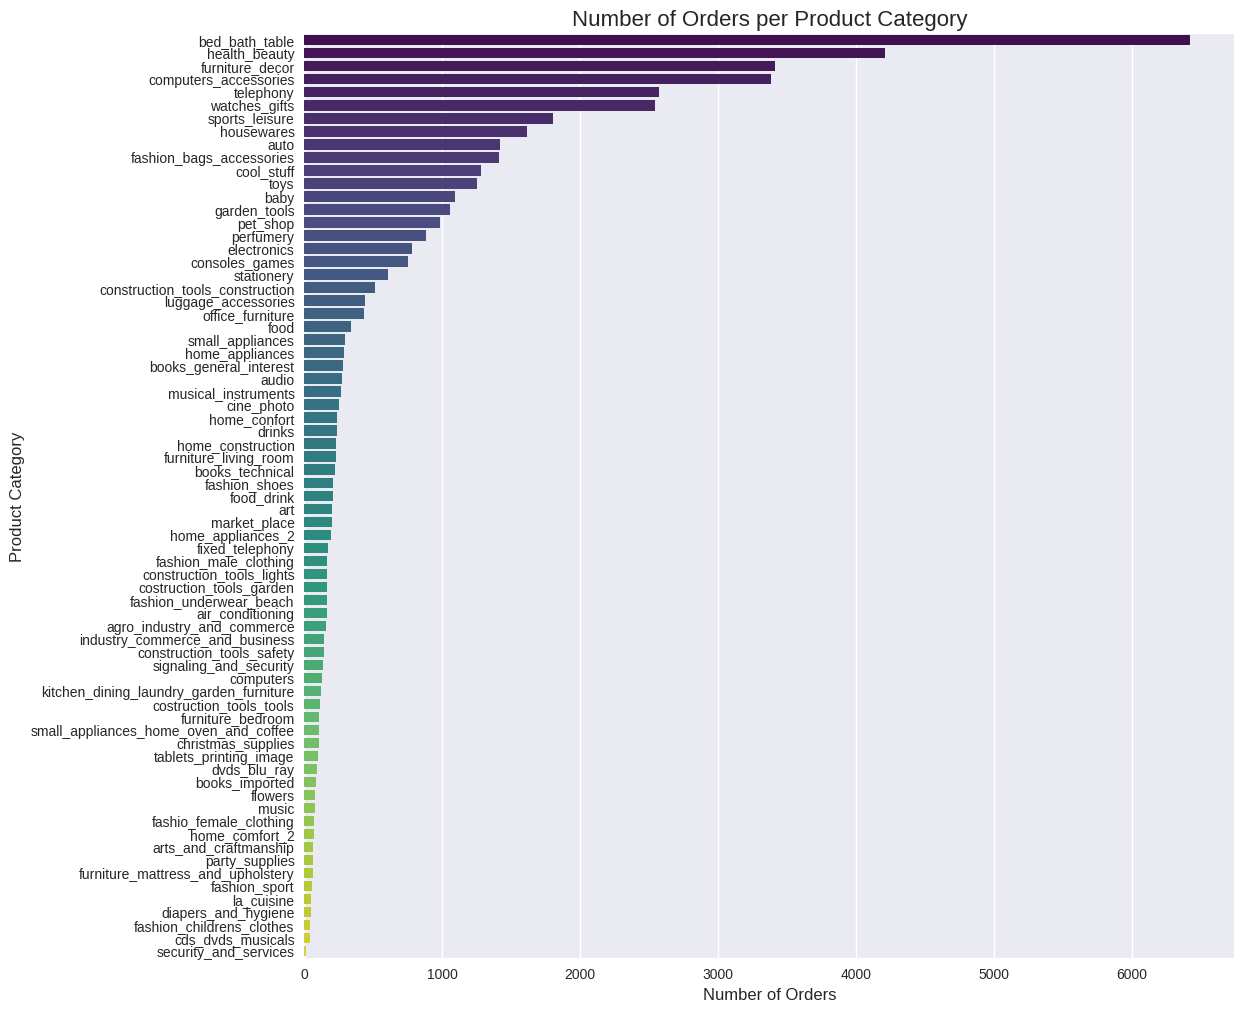

In [ ]:
# ANSWER: bar chart of product categories
# Calculate counts for each category and sort them
cat_counts = df_orders_cleaned['top_product_category'].value_counts().reset_index()
cat_counts.columns = ['top_product_category', 'count']

# Create the plot
plt.figure(figsize=(12, 12)) # Make the figure wide enough
sns.barplot(data=cat_counts, x='count', y='top_product_category', palette='viridis')

# Add labels and title
plt.title('Number of Orders per Product Category', fontsize=16)
plt.xlabel('Number of Orders', fontsize=12)
plt.ylabel('Product Category', fontsize=12)

plt.show()

#### Brief interpretation

**Task:**
- In 2–3 sentences, describe any trends you see (e.g., which categories dominate, whether the distribution is skewed, etc.).

_Write your observations here._

The bar chart shows that **bed_bath_table** and **health_beauty** are the most popular product categories, accounting for a significant portion of the orders. The distribution is **skewed**, with a few top categories dominating the sales, while many other categories have relatively low order counts.

### 2.3 Box Plot: Order Value vs Number of Items (2 mark)

#### Create box plot

**Task:**
- Create a box plot with:
  - X‑axis: `num_items`
  - Y‑axis: `order_total_value`
- Add a clear title and axis labels.

/tmp/ipython-input-3749998017.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_orders_cleaned, x='num_items', y='order_total_value', palette='Blues')


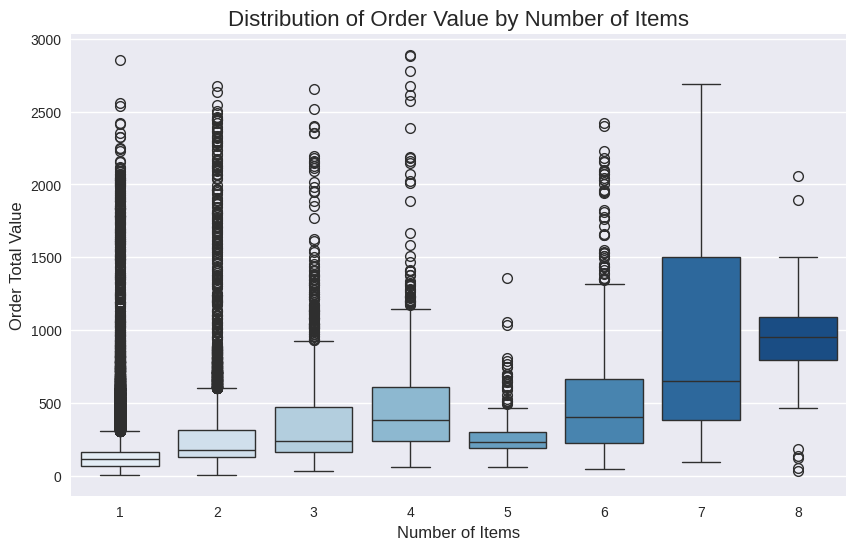

In [ ]:
# ANSWER: box plot order_total_value vs num_items
plt.figure(figsize=(10, 6))

# Create Box Plot
sns.boxplot(data=df_orders_cleaned, x='num_items', y='order_total_value', palette='Blues')

# Add labels and title
plt.title('Distribution of Order Value by Number of Items', fontsize=16)
plt.xlabel('Number of Items', fontsize=12)
plt.ylabel('Order Total Value', fontsize=12)

plt.show()

#### Brief interpretation

**Task:**
- In 2–3 sentences, describe how order value changes as the number of items increases (e.g., linear trend, diminishing returns, many outliers, etc.).

_Write your observations here._

The median order total value increases as the number of items increases. However, the spread of order values also becomes larger for higher item counts. There are several outliers, particularly for orders with a small number of items, indicating some high-value single purchases.